# Galaxy Dataset Preliminary Analysis
This notebook computes signal-to-noise ratios (SNR) for the galaxy images and visualizes their distribution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('src')
from data_prep import thresh_image, norm_image

Matplotlib created a temporary cache directory at /var/folders/hh/v2v4tjkn1rz3fwc890mdwgy00000gn/T/matplotlib-1iur3_ck because the default path (/Users/anna/.matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


ModuleNotFoundError: No module named 'data_prep'

In [ ]:
# Load data
X = np.load('data/galaxy_X.npy')  # images
y = np.load('data/galaxy_y.npy')  # one-hot labels

y_class = np.argmax(y, axis=1)
class_names = ['BENT', 'COMP', 'FRI', 'FRII']

## SNR Histogram (Raw)

In [ ]:
def compute_snr_raw(img):
    """
    Compute signal-to-noise ratio (SNR) on raw (unnormalized) image.
    
    Parameters
    ----------
    img : ndarray
        Raw image array (before normalization).
    
    Returns
    -------
    float
        Signal-to-noise ratio.
    """
    # Convert to float
    img = img.astype(float)
    
    # Define signal as mean of nonzero pixels
    signal = np.mean(img[img > 0]) if np.any(img > 0) else np.nan
    
    # Define noise as std of background pixels (zeros or very low values)
    background = img[img <= 0] if np.any(img <= 0) else img
    noise = np.std(background) if background.size > 0 else np.nan
    
    if noise == 0 or np.isnan(noise):
        return np.nan
    return signal / noise

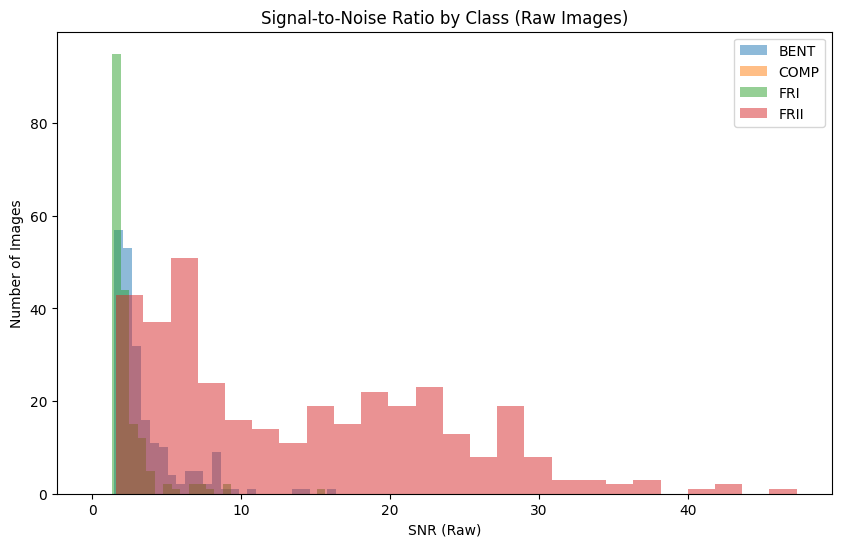

In [ ]:
# Raw SNR histograms
plt.figure(figsize=(10,6))
for i, cname in enumerate(class_names):
    class_snrs = np.array([compute_snr_raw(img) for img, label in zip(X, y_class) if label == i])
    class_snrs = class_snrs[~np.isnan(class_snrs)]
    plt.hist(class_snrs, bins=25, alpha=0.5, label=cname)

plt.xlabel("SNR (Raw)")
plt.ylabel("Number of Images")
plt.title("Signal-to-Noise Ratio by Class (Raw Images)")
plt.legend()
plt.show()

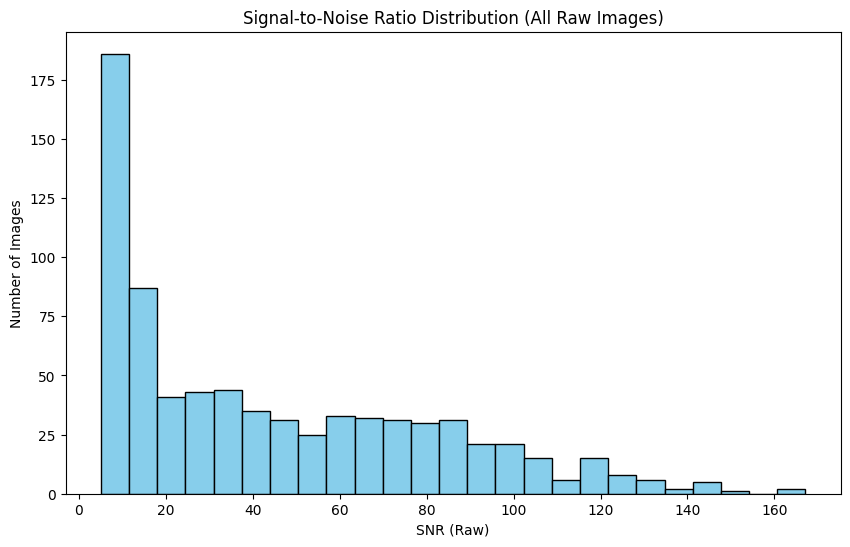

In [ ]:
# Compute SNRs on all raw images (before normalization)
snr_raw_all = np.array([compute_snr_raw(img) for img in X])
snr_raw_all = snr_raw_all[~np.isnan(snr_raw_all)]

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(snrs, bins=25, color='skyblue', edgecolor='black')
plt.xlabel("SNR (Raw)")
plt.ylabel("Number of Images")
plt.title("Signal-to-Noise Ratio Distribution (All Raw Images)")
plt.show()

## SNR Histogram

In [ ]:
# Function to compute SNR for one image
def compute_snr(img):
    # Normalize image to [0,1]
    img_norm = norm_image(img)
    
    # Threshold to get galaxy pixels
    threshed, _ = thresh_image(img_norm)
    
    signal = img_norm[threshed == 1]
    background = img_norm[threshed == 0]
    
    if len(signal) == 0 or len(background) == 0:
        return np.nan
    
    snr = np.mean(signal) / (np.std(background) + 1e-8)
    return snr

In [ ]:
# Compute SNR for all images
snrs = np.array([compute_snr(img) for img in X])

# Remove NaN images if any
snrs = snrs[~np.isnan(snrs)]

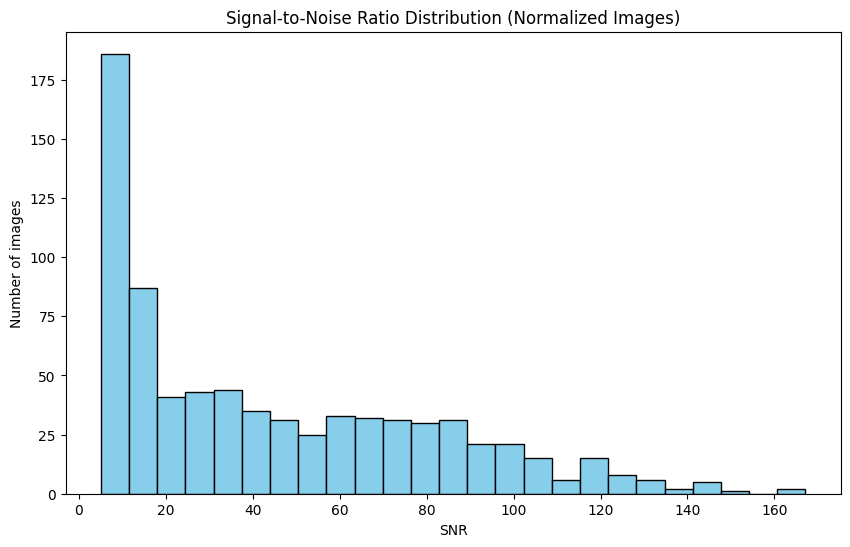

In [ ]:
# %%
# Plot overall SNR histogram
plt.figure(figsize=(10,6))
plt.hist(snrs, bins=25, color='skyblue', edgecolor='black')
plt.xlabel("SNR")
plt.ylabel("Number of images")
plt.title("Signal-to-Noise Ratio Distribution (Normalized Images)")
plt.show()

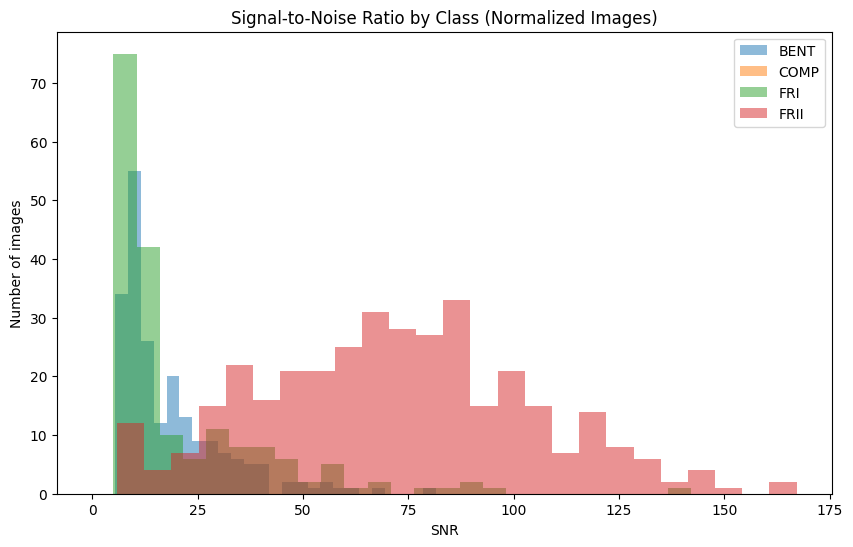

In [ ]:
# %%
# Plot per-class SNR histograms
plt.figure(figsize=(10,6))
for i, cname in enumerate(class_names):
    class_snrs = np.array([compute_snr(img) for img, label in zip(X, y_class) if label == i])
    class_snrs = class_snrs[~np.isnan(class_snrs)]
    plt.hist(class_snrs, bins=25, alpha=0.5, label=cname)
plt.xlabel("SNR")
plt.ylabel("Number of images")
plt.title("Signal-to-Noise Ratio by Class (Normalized Images)")
plt.legend()
plt.show()

In [ ]:
for i, cname in enumerate(class_names):
    class_snrs = np.array([compute_snr(img) for img, label in zip(X, y_class) if label == i])
    class_snrs = class_snrs[~np.isnan(class_snrs)]
    print(f"{cname} median SNR: {np.median(class_snrs):.1f}")

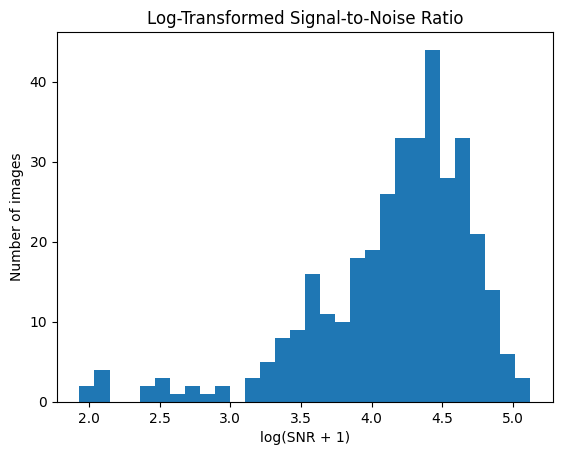

In [ ]:
import numpy as np
snr_log = np.log1p(class_snrs)  # log(1 + SNR) avoids log(0)
plt.hist(snr_log, bins=30)
plt.xlabel("log(SNR + 1)")
plt.ylabel("Number of images")
plt.title("Log-Transformed Signal-to-Noise Ratio")
plt.show()

## SNR Improvement

In [ ]:
snr_raw = []
snr_thresh = []

for img in X:  # use all images    
    # SNR on raw normalized image
    snr_val = compute_snr(img_norm)
    if not np.isnan(snr_val):
        snr_raw.append(snr_val)
    
    # Convert boolean to float to safely compute SNR
    threshed_float = threshed.astype(float)
    
    # SNR on thresholded image
    snr_val_thresh = compute_snr(threshed_float)
    if not np.isnan(snr_val_thresh):
        snr_thresh.append(snr_val_thresh)

# Boxplot
plt.figure(figsize=(10,6))
plt.boxplot([snr_raw, snr_thresh], labels=["Raw", "Thresholded"])
plt.ylabel("Signal-to-Noise Ratio")
plt.title("Effect of Pre-processing on SNR")
plt.show()

NameError: name 'img_norm' is not defined

## Pixel Intensity Distributions

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(img.flatten(), bins=50, alpha=0.5, label='Raw')
plt.hist(img_norm.flatten(), bins=50, alpha=0.5, label='Normalized')
plt.hist(threshed.flatten(), bins=50, alpha=0.5, label='Thresholded')
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.title("Effect of Pre-processing on Pixel Values")
plt.legend()
plt.show()